In [1]:
!pip install huggingface_hub
!pip install hf_xet
!pip install -U transformers bitsandbytes
!pip install contractions
!pip install sentence-transformers
!pip install evaluate
!pip install trl
!pip install -U peft
!pip install -U nltk
!pip install bert_score
!pip install sacrebleu
!pip install mauve-text
!pip install git+https://github.com/google-research/bleurt.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 93.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 24.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 82.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Librerie
import nltk
import json
import torch
import zipfile
import evaluate
import numpy as np
import contractions
import pandas as pd
import seaborn as sns
from datasets import Dataset
from textblob import TextBlob
from tqdm.notebook import tqdm
from nltk.corpus import wordnet
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import word_tokenize, pos_tag
from huggingface_hub import notebook_login
from huggingface_hub.hf_api import HfFolder
from IPython.display import display, Markdown
from nltk.translate.meteor_score import meteor_score
from sklearn.model_selection import train_test_split
from peft import LoraConfig, get_peft_model, TaskType
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    AutoModel,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    pipeline
)

HfFolder.save_token("TOKEN")

 
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

2025-07-18 08:40:21.533189: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752828021.894018      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752828022.002321      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading pac

True

In [3]:
with open("/kaggle/input/llmsresponses/llama_ft_responses.json", "r") as file:
    data_llama = json.load(file)

with open("/kaggle/input/llmsresponses/gemma3_ft_responses.json", "r") as file:
    data_gemma3 = json.load(file)

with open("/kaggle/input/llmsresponses/qwen_ft_responses.json", "r") as file:
    data_qwen = json.load(file)

In [4]:
df = pd.read_csv('/kaggle/input/mental-health/train_with_classification.csv')

unique_questions = df['Context'].unique()

train_questions, test_questions = train_test_split(unique_questions, test_size=0.25, random_state=42)

train_dataset = df[df['Context'].isin(train_questions)]
test_dataset = df[df['Context'].isin(test_questions)]

 
td = Dataset.from_pandas(train_dataset)
test_td = Dataset.from_pandas(test_dataset)

train_clean = td.filter(lambda example: example['Response'] is not None and example['Response'] != '')
test_clean = test_td.filter(lambda example: example['Response'] is not None and example['Response'] != '')

Filter:   0%|          | 0/2731 [00:00<?, ? examples/s]

Filter:   0%|          | 0/776 [00:00<?, ? examples/s]

In [5]:
def create_conversation(sample):
    context = sample['Context']
    response = sample['Response']

    return {
        "messages": [
            {"role": "user", "content": context},
            {"role": "assistant", "content": response}
        ]
    }

def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer_llama.apply_chat_template(convo, tokenize = False, add_generation_prompt = False).removeprefix('<bos>') for convo in convos]
    return { "text" : texts, }

In [6]:
test_dataset = test_clean.map(create_conversation, batched=False)

Map:   0%|          | 0/776 [00:00<?, ? examples/s]

In [7]:
neutrale = []
generico = []
specializzato = []

df = pd.DataFrame(test_dataset)
df = df.iloc[:, :3]
for item in data_llama.get("domande", []):
    neutrale.append(item.get("neutrale", ""))
    generico.append(item.get("generico", ""))
    specializzato.append(item.get("specializzato", ""))

df["llama neutrale"] = neutrale
df["llama generico"] = generico
df["llama specializzato"] = specializzato

neutrale = []
generico = []
specializzato = []

for item in data_gemma3.get("domande", []):
    neutrale.append(item.get("neutrale", ""))
    generico.append(item.get("generico", ""))
    specializzato.append(item.get("specializzato", ""))

df["gemma3 neutrale"] = neutrale
df["gemma3 generico"] = generico
df["gemma3 specializzato"] = specializzato

neutrale = []
generico = []
specializzato = []

for item in data_qwen.get("domande", []):
    neutrale.append(item.get("neutrale", ""))
    generico.append(item.get("generico", ""))
    specializzato.append(item.get("specializzato", ""))

df["qwen neutrale"] = neutrale
df["qwen generico"] = generico
df["qwen specializzato"] = specializzato

df.to_csv("test_dataset.csv", index=False)

In [8]:
df.head(3)

,Context,Response,Disorders,llama neutrale,llama generico,llama specializzato,gemma3 neutrale,gemma3 generico,gemma3 specializzato,qwen neutrale,qwen generico,qwen specializzato
0,I have been feeling more and more down for ove...,Answers about our inner lives are most success...,"Acute Stress Disorder, Adjustment Disorder wit...",I'm sorry to hear that you're feeling down and...,It sounds like you're going through a very dif...,It sounds like you're going through a very dif...,I'm so sorry to hear you're going through this...,It sounds like you're going through a very dif...,Hello. Thank you for sharing that with me. It ...,I'm very sorry to hear that you've been going ...,Feeling as you do sounds extremely challenging...,I can tell that you have been going through a ...
1,I have been feeling more and more down for ove...,It could be really helpful to see a counselor/...,"Acute Stress Disorder, Anxiety Disorder due to...",I'm so sorry to hear that you're going through...,It sounds like you're going through a very dif...,It sounds like you're going through a really t...,I'm so sorry to hear you're going through this...,It sounds like you're currently experiencing a...,Hello. Thank you for sharing that with me. It ...,I'm very sorry to hear that you've been feelin...,I understand that feeling down for a sustained...,"I can truly understand how you feel, and it so..."
2,I’m facing severe depression and anxiety and I...,Have you used meditation or hypnosis? Relaxing...,"Acute Stress Disorder, Anxiety Disorder, Depre...",I'm sorry to hear that you're going through th...,It takes a lot of courage to share your feelin...,I'm so sorry to hear that you're going through...,It takes a lot of courage to even talk about f...,It sounds like you're currently experiencing a...,Hello. Thank you for sharing that with me. It ...,I'm sorry to hear that you are going through a...,"I can't offer professional advice here, but I'...",I can imagine how challenging this must be for...


In [9]:
bertscore = evaluate.load("bertscore")
bleurt = evaluate.load("bleurt")

def get_similarity(reference,generated):
    vectorizer = TfidfVectorizer()
    tfidf = vectorizer.fit_transform([generated, reference])
    return cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]
    
def get_bertscore(reference, generated):
    score = bertscore.compute(predictions=[generated], references=[reference], lang="en")
    return score['f1'][0]

def get_bleurt(reference, generated):
    score = bleurt.compute(predictions=[generated], references=[reference])
    return score['scores'][0]
    
def get_meteor(reference, generated):
    return meteor_score([word_tokenize(reference)], word_tokenize(generated))

I0000 00:00:1752828110.786582      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1752828110.787373      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:
def evaluate_metrics(row,model_name):
    prompts = ['neutrale','generico','specializzato']
    result = {}
    
    reference = row['Response']
    for prompt in prompts:
        generated = row[f'{model_name} {prompt}']

        # Similarity
        sim = get_similarity(reference,generated)
        result[f'similarity {prompt}'] = sim

        # Bertscore
        bertscore = get_bertscore(reference,generated)
        result[f'bertscore {prompt}'] = bertscore

        # Meteor
        meteor = get_meteor(reference,generated)
        result[f'meteor {prompt}'] = meteor 
        
        # Bleurt
        bleurt = get_bleurt(reference,generated)
        result[f'bleurt {prompt}'] = bleurt 

    return result


In [11]:
def plot_metriche(df_metriche,model_name):
    metriche = ['similarity', 'bertscore', 'meteor', 'bleurt']
    prompt = ['neutrale', 'generico', 'specializzato']
    
    data = {'metrica': [], 'prompt': [], 'valore': []}
    
    for m in metriche:
        for p in prompt:
            col_name = f"{m} {p}"
            data['metrica'].append(m)
            data['prompt'].append(p)
            data['valore'].append(df_metriche[col_name].mean())
    
    df_plot = pd.DataFrame(data)
    
    
    sns.set(style="whitegrid", font_scale=1.2)
    plt.figure(figsize=(10, 6))
    
    ax = sns.barplot(
        data=df_plot,
        x='metrica',
        y='valore',
        hue='prompt',
        palette='viridis'
    )
    
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3,fontsize=8)
    
    plt.title(f"Confronto delle metriche per tipo di prompt - {model_name}", fontsize=16)
    plt.xlabel("Metrica")
    plt.ylabel("Valore medio")
    plt.legend(title="Prompt")
    plt.tight_layout()
    plt.savefig(f"metriche.jpg", format='jpg')
    plt.show()

In [12]:
df_test = pd.read_csv('/kaggle/working/test_dataset.csv')
df_test = df_test.map(lambda x: x.replace('\n', '') if isinstance(x, str) else x)

In [13]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [ ]:
tqdm.pandas(desc="Calcolo delle metriche...")
df_metriche_qwen = df_test.progress_apply(lambda row: evaluate_metrics(row, 'llama'), 
                                          axis=1, result_type='expand')
df_metriche_qwen.to_csv("metriche_llama.csv", index=False)

In [15]:
tqdm.pandas(desc="Calcolo delle metriche...")
df_metriche_qwen = df_test.progress_apply(lambda row: evaluate_metrics(row, 'gemma3'), 
                                          axis=1, result_type='expand')
df_metriche_qwen.to_csv("metriche_gemma3.csv", index=False)

Calcolo delle metriche...:   0%|          | 0/776 [00:00<?, ?it/s]

In [16]:
tqdm.pandas(desc="Calcolo delle metriche...")
df_metriche_qwen = df_test.progress_apply(lambda row: evaluate_metrics(row, 'qwen'), 
                                          axis=1, result_type='expand')
df_metriche_qwen.to_csv("metriche_qwen.csv", index=False)

Calcolo delle metriche...:   0%|          | 0/776 [00:00<?, ?it/s]

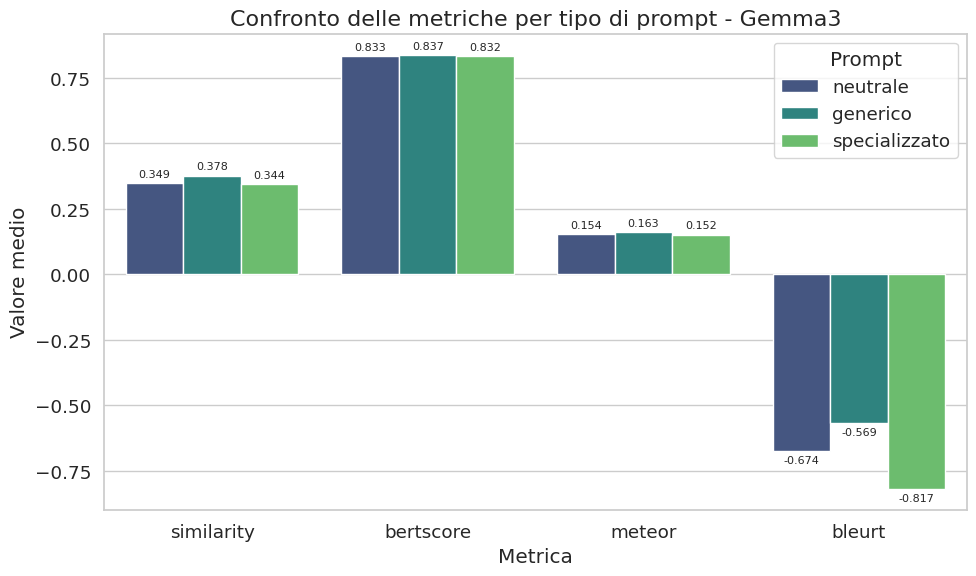

In [15]:
df_metriche_meta = pd.read_csv('/kaggle/input/metrichellms/metriche_gemma3.csv')
plot_metriche(df_metriche_meta,'Gemma3')

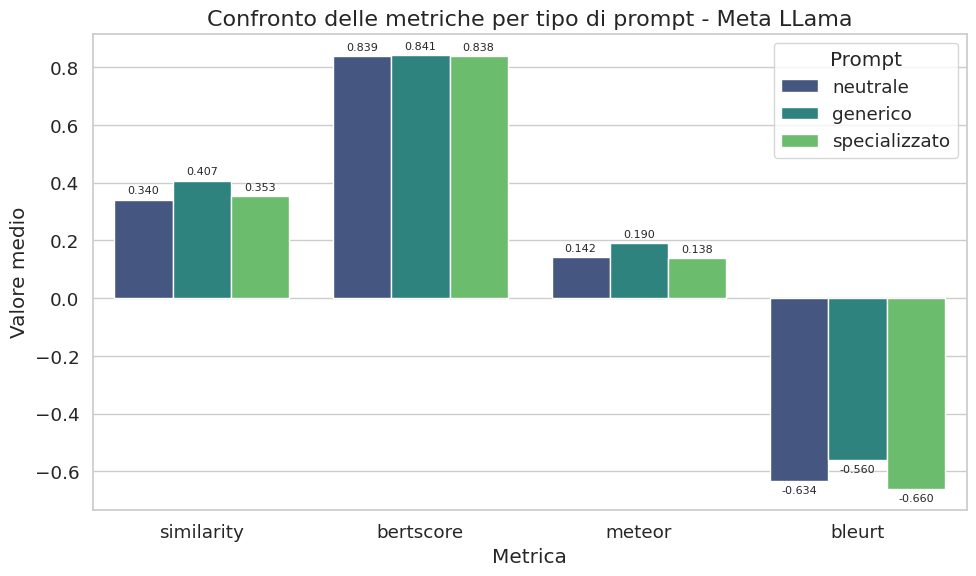

In [16]:
df_metriche_meta = pd.read_csv('/kaggle/input/metrichellms/metriche_llama.csv')
plot_metriche(df_metriche_meta,'Meta LLama')

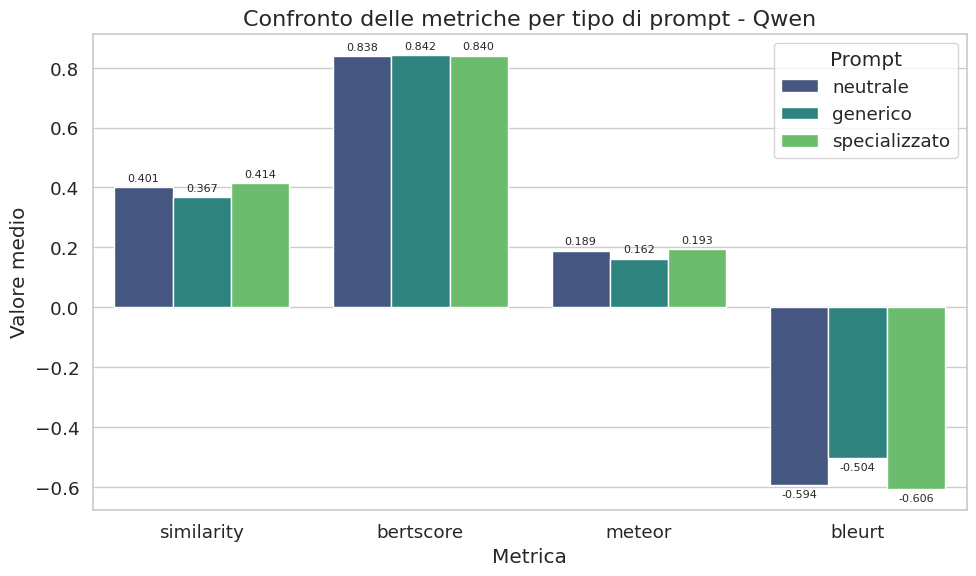

In [17]:
df_metriche_meta = pd.read_csv('/kaggle/input/metrichellms/metriche_qwen.csv')
plot_metriche(df_metriche_meta,'Qwen')

In [18]:
 
lemmatizer = WordNetLemmatizer()

 
custom_stopwords = set([
    "thing", "anything", "lot", "time", 
    "year", "people", "someone", "something", 
    "life", "month", "point", "way", "issue",
    "interest", "nothing", "problem", "everything",
    "day"
])

 
def penn_to_wordnet(tag):
    if tag.startswith('N'):
        return wordnet.NOUN
    else:
        return None

 
def expand_contractions(text):
    return contractions.fix(text)

 
def custom_tokenizer(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tagged_tokens = pos_tag(tokens)
    
    lemmatized = []
    for word, tag in tagged_tokens:
        if len(word) > 2 and word not in custom_stopwords:  # filtro lunghezza + stopword personalizzate
            wn_tag = penn_to_wordnet(tag)
            if wn_tag == wordnet.NOUN:
                lemma = lemmatizer.lemmatize(word, pos=wn_tag)
                if lemma not in custom_stopwords:  # stopword anche dopo lemmatizzazione
                    lemmatized.append(lemma)
    
    return lemmatized

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

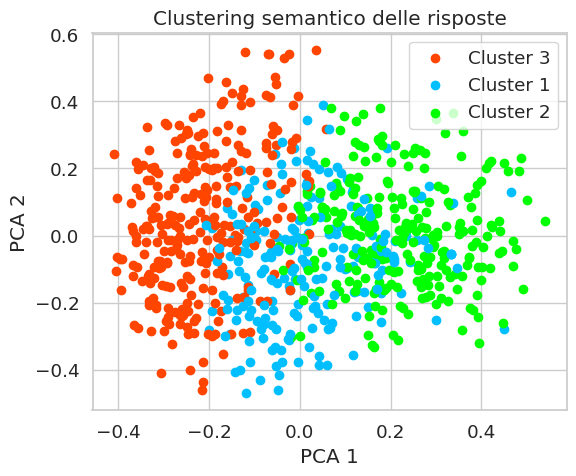

### <span style='color:deepskyblue;'>Cluster 1 (228 risposte)</span>

 Parole chiave: anxiety, attack, family, feeling, forever, friend, personality, relationship, school, thought

### <span style='color:lime;'>Cluster 2 (261 risposte)</span>

 Parole chiave: boyfriend, child, friend, husband, love, mom, relationship, sex, week, wife

### <span style='color:orangered;'>Cluster 3 (287 risposte)</span>

 Parole chiave: anxiety, binge, depression, disorder, family, friend, night, relationship, stress, voice

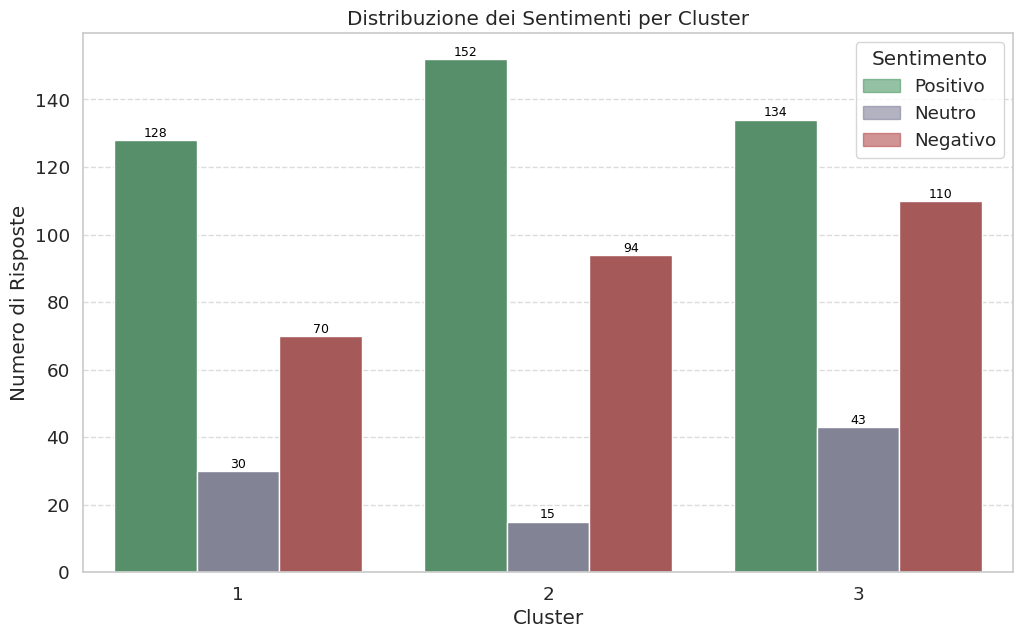

In [26]:
model = SentenceTransformer('all-MiniLM-L6-v2')
model_n = 'llama'
spec = 'specializzato'
embeddings = model.encode(df[f'{model_n} {spec}'].tolist())

 
pca = PCA(n_components=5)
reduced_KMeans = pca.fit_transform(embeddings)

 
n_clusters = 3
kmeans = KMeans(n_init='auto', n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(reduced_KMeans)
df['cluster'] = labels

 
cluster_sizes = df['cluster'].value_counts().sort_values(ascending=False)

 
color_map = {0: 'deepskyblue',
             1: 'lime',
             2: 'orangered'}

 
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

 
plt.figure(figsize=(6, 5))

 
for i, (x, y) in enumerate(reduced):
    plt.scatter(x, y, color=color_map[labels[i]], label=f'Cluster {labels[i]+1}' if f'Cluster {labels[i]+1}' not in plt.gca().get_legend_handles_labels()[1] else "")

 
plt.title("Clustering semantico delle risposte")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.tight_layout()

 
plt.savefig(f'cluster_sem_{model_n}_{spec}.png', bbox_inches='tight')
plt.show()

 
all_data = []

for cluster_id in range(n_clusters):
    cluster_risposte = df[df['cluster'] == cluster_id]['Context'].tolist()
    
    
    cluster_risposte = [expand_contractions(t) for t in cluster_risposte]
    
    
    tfidf = TfidfVectorizer(tokenizer=custom_tokenizer, lowercase=True, max_features=10, token_pattern=None)
    tfidf_matrix = tfidf.fit_transform(cluster_risposte)
    keywords = tfidf.get_feature_names_out()

    
    cluster_color = color_map[cluster_id]  
    cluster_title = f"<span style='color:{cluster_color};'>Cluster {cluster_id + 1} ({len(cluster_risposte)} risposte)</span>"
    keyword_line  = f"Parole chiave: {', '.join(keywords)}"
    
    
    display(Markdown(f"### {cluster_title}"))
    display(Markdown(f"{keyword_line}"))

    
    for text in cluster_risposte:
        polarity = TextBlob(text).sentiment.polarity
        sentiment = 'positivo' if polarity > 0 else 'negativo' if polarity < 0 else 'neutro'
        all_data.append({'cluster': cluster_id, 'sentiment': sentiment})

 
df_all = pd.DataFrame(all_data)

 
palette = {
    'positivo': (0.3, 0.6, 0.4, 0.6),    
    'neutro':   (0.5, 0.5, 0.6, 0.6),    
    'negativo': (0.7, 0.3, 0.3, 0.6)     
}

plt.figure(figsize=(12,7))
ax = sns.countplot(
    data=df_all, x='cluster', hue='sentiment', order=range(n_clusters),
    hue_order=['positivo', 'neutro', 'negativo'],
    palette=palette
)
ax.set_xticklabels([str(i+1) for i in range(n_clusters)])

plt.title("Distribuzione dei Sentimenti per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Numero di Risposte")
plt.grid(axis='y', linestyle='--', alpha=0.7)

 
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            x=p.get_x() + p.get_width() / 2,
            y=height + 0.1,
            s=int(height),
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

# Crea legenda personalizzata con numero totale parole
handles = [
    mpatches.Patch(color=palette['positivo'], label=f"Positivo"),
    mpatches.Patch(color=palette['neutro'], label=f"Neutro"),
    mpatches.Patch(color=palette['negativo'], label=f"Negativo")
]

plt.legend(title='Sentimento', handles=handles, loc='upper right')
plt.savefig(f'distr_sen_cluster_{model_n}_{spec}.png', bbox_inches='tight')
plt.show()


---